In [1]:
%load_ext cython

In [24]:
# Cell 1: Setup and Imports
%load_ext cython
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Dict, Any, Optional
import warnings
import json
import time
from pathlib import Path
import threading
import queue
import concurrent.futures
import requests
import os
import sys
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("=== ENHANCED LLM-INTEGRATED ENVIRONMENT ===")

# Enhanced Configuration Memory with LLM Feedback
class LLMEnhancedConfigurationMemory:
    def __init__(self):
        self.successful_configs = []
        self.failed_configs = []
        self.performance_history = []
        self.best_ever_config = None
        self.best_ever_hv = 0
        self.llm_suggestions = []  # Track LLM suggestions
        self.operator_performance = {}  # Track operator effectiveness
        self.parameter_regions = {}  # Track performance by parameter regions
        
    def add_result(self, config, success, hv_improvement, runtime, hv, operator_strategy=None):
        result = {
            'config': config,
            'success': success,
            'hv_improvement': hv_improvement,
            'runtime': runtime,
            'hv': hv,
            'timestamp': time.time(),
            'operator_strategy': operator_strategy
        }
        
        # Track operator performance
        if operator_strategy:
            op_key = '_'.join(operator_strategy)
            if op_key not in self.operator_performance:
                self.operator_performance[op_key] = []
            self.operator_performance[op_key].append(hv_improvement)
        
        # Track parameter region
        region_key = (config['alpha']//5, int(config['kappa']*100)//1, config['L'])
        if region_key not in self.parameter_regions:
            self.parameter_regions[region_key] = []
        self.parameter_regions[region_key].append(hv_improvement)
        
        # Track best ever configuration
        if hv > self.best_ever_hv:
            self.best_ever_hv = hv
            self.best_ever_config = config.copy()
            
        if success and hv_improvement > 0:
            self.successful_configs.append(result)
        else:
            self.failed_configs.append(result)
        self.performance_history.append(result)
    
    def get_best_operators(self, top_n=3):
        """Get top performing operator strategies"""
        if not self.operator_performance:
            return ['swap', 'greedy_add', 'mutation']
        
        avg_performance = {}
        for op, improvements in self.operator_performance.items():
            avg_performance[op] = np.mean(improvements)
        
        sorted_ops = sorted(avg_performance.items(), key=lambda x: x[1], reverse=True)
        return [op.split('_') for op, _ in sorted_ops[:top_n]]
    
    def get_best_regions(self, top_n=3):
        """Get top performing parameter regions"""
        if not self.parameter_regions:
            return [(30, 10, 4)]
        
        avg_performance = {}
        for region, improvements in self.parameter_regions.items():
            avg_performance[region] = np.mean(improvements)
        
        sorted_regions = sorted(avg_performance.items(), key=lambda x: x[1], reverse=True)
        return sorted_regions[:top_n]

# Initialize global memory
config_memory = LLMEnhancedConfigurationMemory()

# Load the true reference Pareto front
def load_true_reference_pareto_front(reference_file="./result250.txt"):
    """Load the reference results and extract the true Pareto front"""
    try:
        data = np.loadtxt(reference_file)
        data_unique = np.unique(data, axis=0)
        
        def is_pareto_efficient(points):
            """Find the indices of Pareto-efficient points (maximization)"""
            is_efficient = np.ones(points.shape[0], dtype=bool)
            for i, c in enumerate(points):
                if is_efficient[i]:
                    is_efficient[is_efficient] = np.any(points[is_efficient]>=c, axis=1)
                    is_efficient[i] = True
            return is_efficient
        
        pareto_mask = is_pareto_efficient(data_unique)
        pareto_points = data_unique[pareto_mask]
        
        return {
            'all_solutions': data,
            'unique_solutions': data_unique,
            'pareto_solutions': pareto_points,
            'num_pareto': len(pareto_points)
        }
    except Exception as e:
        print(f"Error loading reference file: {e}")
        return None

# Calculate hypervolume function with improved precision
def calculate_hypervolume_2d(pareto_front, reference_point=None):
    """Calculate 2D hypervolume of Pareto front with improved precision"""
    if len(pareto_front) == 0:
        return 0.0
    if reference_point is None:
        reference_point = np.array([0.0, 0.0])
    sorted_front = pareto_front[np.argsort(pareto_front[:, 0])]
    hypervolume = 0.0
    prev_x = reference_point[0]
    for point in sorted_front:
        width = point[0] - prev_x
        height = point[1] - reference_point[1]
        if width > 0 and height > 0:
            hypervolume += width * height
        prev_x = point[0]
    return hypervolume

# Load data
print("Loading true reference Pareto front...")
true_reference = load_true_reference_pareto_front()

if true_reference:
    true_reference_hv = calculate_hypervolume_2d(true_reference['pareto_solutions'])
    # Set a more achievable target (3% improvement for more ambitious goal)
    target_hv = true_reference_hv * 1.03
    print(f"✓ True Reference HV: {true_reference_hv:,.0f}")
    print(f"✓ Target HV (3% improvement): {target_hv:,.0f}")
else:
    print("⚠ Could not load true reference data, using default values")
    true_reference_hv = 97640877
    target_hv = true_reference_hv * 1.03

# Initialize results summary
results_summary = {
    'True_Reference': {
        'hv': true_reference_hv,
        'time': 0.12,
        'num_solutions': true_reference['num_pareto'] if true_reference else 236,
        'efficiency': true_reference_hv / 0.12
    }
}

print("\n=== LLM-ENHANCED ENVIRONMENT READY ===")
print(f"True Reference HV: {true_reference_hv:,.0f}")
print(f"Target HV: {target_hv:,.0f}")
print("Ready for LLM-enhanced optimization...")

The cython extension is already loaded. To reload it, use:
  %reload_ext cython
=== ENHANCED LLM-INTEGRATED ENVIRONMENT ===
Loading true reference Pareto front...
✓ True Reference HV: 97,640,877
✓ Target HV (3% improvement): 100,570,103

=== LLM-ENHANCED ENVIRONMENT READY ===
True Reference HV: 97,640,877
Target HV: 100,570,103
Ready for LLM-enhanced optimization...


In [25]:
# Cell 2: Enhanced LLM Interface with Increased Timeouts (IMPROVED VERSION)
class EnhancedLLaMA3Interface:
    """Enhanced LLaMA-3 interface with increased timeouts and better error handling"""
    
    def __init__(self, model_path="llama3:latest", temperature=0.7, max_tokens=500):
        self.model_path = model_path
        self.temperature = temperature
        self.max_tokens = max_tokens
        self.cache = {}  # Cache responses to avoid repeated calls
        self.call_count = 0
        self.successful_calls = 0
        self.failed_calls = 0
        self.connection_status = None
        self.problem_knowledge = {
            'multi_objective_knapsack': {
                'key_parameters': ['alpha', 'kappa', 'L'],
                'parameter_effects': {
                    'alpha': 'Higher values increase exploration but may reduce convergence speed',
                    'kappa': 'Lower values increase selection pressure, higher values promote diversity',
                    'L': 'Controls neighborhood size in local search'
                },
                'operator_effects': {
                    'swap': 'Good for fine-tuning solutions by exchanging items',
                    'greedy_add': 'Effective for quickly improving solution quality',
                    'mutation': 'Helps escape local optima by making random changes'
                }
            }
        }
        self._verify_connection()
        
    def _verify_connection(self):
        """Verify if LLaMA-3 is accessible with more robust checking"""
        print("🔍 Verifying LLaMA-3 connection...")
        
        # Test Ollama connection with multiple attempts
        max_attempts = 3
        for attempt in range(max_attempts):
            try:
                response = requests.get('http://localhost:11434/api/tags', timeout=50)  # Increased timeout
                if response.status_code == 200:
                    models = response.json().get('models', [])
                    model_names = [model['name'] for model in models]
                    
                    if self.model_path in model_names:
                        self.connection_status = "ollama_connected"
                        print(f"✅ Ollama connected with {self.model_path} available")
                        return True
                    else:
                        print(f"⚠️ Ollama connected but {self.model_path} not found")
                        print(f"Available models: {model_names}")
                        self.connection_status = "ollama_no_model"
                        return False
                else:
                    print(f"❌ Ollama API returned status {response.status_code} (attempt {attempt+1}/{max_attempts})")
            except Exception as e:
                print(f"❌ Ollama connection failed (attempt {attempt+1}/{max_attempts}): {e}")
                if attempt < max_attempts - 1:
                    time.sleep(2)  # Wait longer before retrying
        
        print("❌ No LLaMA-3 connection available - using rule-based optimization")
        self.connection_status = "ollama_unavailable"
        return False
    
    def _call_ollama(self, prompt):
        """Call local Ollama API for LLaMA-3 with significantly increased timeouts"""
        try:
            # Add a timeout buffer to prevent hanging
            response = requests.post(
                'http://localhost:11434/api/generate',
                json={
                    'model': self.model_path,
                    'prompt': prompt,
                    'stream': False,
                    'options': {
                        'temperature': self.temperature,
                        'num_predict': min(self.max_tokens, 150),  # Reduced tokens to prevent timeouts
                        'timeout': 50  # Significantly increased timeout
                    }
                },
                timeout=50  # Significantly increased overall timeout
            )
            if response.status_code == 200:
                self.successful_calls += 1
                return response.json()['response']
            else:
                self.failed_calls += 1
                print(f"⚠️ LLM API returned status {response.status_code}")
                return None
        except requests.exceptions.Timeout:
            self.failed_calls += 1
            print("⚠️ LLM call timed out")
            return None
        except Exception as e:
            self.failed_calls += 1
            print(f"⚠️ LLM call failed: {str(e)}")
            return None
    
    def _parse_json_response(self, response):
        """Safely parse JSON response from LLM"""
        try:
            # Try to extract JSON from code blocks first
            if '```json' in response:
                # Extract content between ```json and ```
                start = response.find('```json') + 7
                end = response.find('```', start)
                if end != -1:
                    json_str = response[start:end].strip()
                    return json.loads(json_str)
            elif '```' in response:
                # Extract content between any code blocks
                start = response.find('```') + 3
                end = response.find('```', start)
                if end != -1:
                    json_str = response[start:end].strip()
                    # Remove potential language identifiers
                    if json_str.startswith('json'):
                        json_str = json_str[4:].strip()
                    return json.loads(json_str)
            else:
                # Try to parse the entire response as JSON
                return json.loads(response)
        except (json.JSONDecodeError, KeyError, IndexError, AttributeError) as e:
            print(f"Failed to parse JSON response: {e}")
            return None
    
    def generate_config_suggestion(self, current_state, performance_history, adaptive_bounds):
        """Generate configuration suggestion using LLaMA-3 with problem-specific knowledge"""
        
        self.call_count += 1
        
        # Create a cache key based on current state
        cache_key = (current_state.get('hv', 0), current_state.get('alpha', 0), 
                    current_state.get('kappa', 0), current_state.get('L', 0))
        
        # Check cache first
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        # Check if LLM is available
        if self.connection_status != "ollama_connected":
            return self._generate_knowledge_based_config(current_state, adaptive_bounds)
        
        # Prepare prompt with problem-specific knowledge
        current_hv = current_state.get('hv', 0)
        reference_hv = current_state.get('reference_hv', 97640877)
        target_hv = reference_hv * 1.03
        gap_to_target = target_hv - current_hv
        
        # Analyze recent performance trends
        recent_trend = "stable"
        if len(performance_history) > 2:
            recent_hvs = [h['hv'] for h in performance_history[-3:]]
            if recent_hvs[-1] > recent_hvs[-2] > recent_hvs[-3]:
                recent_trend = "improving"
            elif recent_hvs[-1] < recent_hvs[-2] < recent_hvs[-3]:
                recent_trend = "declining"
        
        # Even more simplified prompt to reduce complexity and improve success rate
        prompt = f"""Current HV: {current_hv:,.0f}, target: {target_hv:,.0f}, gap: {gap_to_target:,.0f}.
Current: alpha={current_state.get('alpha', 0)}, kappa={current_state.get('kappa', 0):.3f}, L={current_state.get('L', 0)}.
Trend: {recent_trend}

Suggest new parameters (alpha: 20-60, kappa: 0.03-0.25, L: 2-12).
Return JSON: {{"alpha": int, "kappa": float, "L": int}}"""
        
        response = self._call_ollama(prompt)
        
        if response:
            config = self._parse_json_response(response)
            
            if config:
                # Validate and adjust parameters
                config['alpha'] = min(60, max(20, int(config.get('alpha', 35))))
                config['kappa'] = min(0.25, max(0.03, float(config.get('kappa', 0.12))))
                config['L'] = min(12, max(2, int(config.get('L', 5))))
                
                # Add operator strategy
                config['operator_strategy'] = ['swap', 'greedy_add', 'mutation']
                
                # Cache the response
                self.cache[cache_key] = config
                
                print(f"✅ LLM suggestion: α={config['alpha']}, κ={config['kappa']:.3f}, L={config['L']}")
                return config
            else:
                print("Failed to parse LLM response, using knowledge-based config")
                return self._generate_knowledge_based_config(current_state, adaptive_bounds)
        else:
            print("LLM call failed, using knowledge-based config")
            return self._generate_knowledge_based_config(current_state, adaptive_bounds)
    
    def _generate_knowledge_based_config(self, current_state, adaptive_bounds):
        """Generate configuration based on problem knowledge when LLM fails"""
        
        current_hv = current_state.get('hv', 0)
        reference_hv = current_state.get('reference_hv', 97640877)
        target_hv = reference_hv * 1.03
        gap_to_target = target_hv - current_hv
        
        # Use best performing regions
        best_regions = config_memory.get_best_regions(3)
        best_operators = config_memory.get_best_operators(3)
        
        # More intelligent parameter adjustment based on performance trend
        if len(config_memory.performance_history) > 1:
            # Check if we're improving or declining
            recent_hv = config_memory.performance_history[-1]['hv']
            previous_hv = config_memory.performance_history[-2]['hv']
            
            if recent_hv < previous_hv:  # We're declining, need change
                if gap_to_target > 5000000:  # Large gap - more aggressive
                    new_config = {
                        'alpha': min(60, max(20, current_state.get('alpha', 30) - 15)),
                        'kappa': min(0.25, max(0.03, current_state.get('kappa', 0.10) - 0.07)),
                        'L': min(12, max(2, current_state.get('L', 4) - 3)),
                        'small_value': 1e-7
                    }
                else:  # Medium gap - moderate change
                    new_config = {
                        'alpha': min(60, max(20, current_state.get('alpha', 30) - 8)),
                        'kappa': min(0.25, max(0.03, current_state.get('kappa', 0.10) - 0.05)),
                        'L': min(12, max(2, current_state.get('L', 4) - 2)),
                        'small_value': 1e-7
                    }
            else:  # We're improving, continue with current strategy
                if gap_to_target > 5000000:  # Large gap
                    new_config = {
                        'alpha': min(60, max(20, current_state.get('alpha', 30) + 10)),
                        'kappa': min(0.25, max(0.03, current_state.get('kappa', 0.10) + 0.05)),
                        'L': min(12, max(2, current_state.get('L', 4) + 2)),
                        'small_value': 1e-7
                    }
                else:  # Medium gap - fine-tune
                    new_config = {
                        'alpha': min(60, max(20, current_state.get('alpha', 30) + 5)),
                        'kappa': min(0.25, max(0.03, current_state.get('kappa', 0.10) + 0.03)),
                        'L': min(12, max(2, current_state.get('L', 4) + 1)),
                        'small_value': 1e-7
                    }
        else:  # First iteration, use moderate parameters
            new_config = {
                'alpha': 30,
                'kappa': 0.10,
                'L': 4,
                'small_value': 1e-7
            }
        
        # Select best operators
        operator_strategy = ['swap', 'greedy_add', 'mutation']
        
        return {
            'alpha': new_config['alpha'],
            'kappa': new_config['kappa'],
            'L': new_config['L'],
            'operator_strategy': operator_strategy,
            'reasoning': 'Knowledge-based configuration for performance improvement'
        }

# Reinitialize the enhanced LLM interface
try:
    enhanced_llm_interface = EnhancedLLaMA3Interface(model_path="llama3:latest", temperature=0.7)
    
    # Show status
    if enhanced_llm_interface.connection_status == "ollama_connected":
        print("✅ Enhanced LLaMA-3 is working properly!")
        llm_working = True
    else:
        print("⚠️ Enhanced LLaMA-3 is not working properly, using fallback")
        llm_working = False
        
except Exception as e:
    print(f"❌ Failed to initialize Enhanced LLaMA-3: {e}")
    llm_working = False
    enhanced_llm_interface = None

# Enhanced parameter bounds
ENHANCED_PARAMETER_BOUNDS = {
    'alpha': (20, 60),    # Wider range for exploration
    'kappa': (0.03, 0.25), # Wider range for exploration  
    'L': (2, 12),          # Wider range for exploration
    'small_value': (1e-9, 1e-6)
}

print("Enhanced LLM Integration Ready!")
print(f"Parameter bounds: {ENHANCED_PARAMETER_BOUNDS}")

🔍 Verifying LLaMA-3 connection...
✅ Ollama connected with llama3:latest available
✅ Enhanced LLaMA-3 is working properly!
Enhanced LLM Integration Ready!
Parameter bounds: {'alpha': (20, 60), 'kappa': (0.03, 0.25), 'L': (2, 12), 'small_value': (1e-09, 1e-06)}


In [26]:
%%cython
"""
Enhanced MOACP Implementation with Better Solution Quality
- Enhanced performance with better solution generation
- Improved parameter handling
- Better operator selection based on LLM feedback
- Optimized for achieving dominance within time constraints
"""

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp
import numpy as np
import time
import matplotlib.pyplot as plt

# Optimized MHRE Parameters
cdef int OPTIMIZED_ALPHA = 35
cdef float OPTIMIZED_KAPPA = 0.12
cdef int OPTIMIZED_L = 5
cdef float OPTIMIZED_SMALL_VALUE = 1e-7

# Baseline Parameters
cdef int BASELINE_ALPHA = 10
cdef float BASELINE_KAPPA = 0.05
cdef int BASELINE_L = 5
cdef float BASELINE_SMALL_VALUE = 1e-7

# Enhanced bounds
cdef int MAX_ALPHA = 60
cdef float MAX_KAPPA = 0.25
cdef int MAX_L = 12

# Structs
cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Globals
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

cdef void loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()  # item index (ignore)
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

cdef void read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void smart_init_ind(ind *x):
    """Smart initialization that considers item value/weight ratios"""
    cdef int j, r, tmp
    cdef double *ratios = <double *>chk_malloc(ni * sizeof(double))
    
    # Calculate value/weight ratios for each item
    for j in range(ni):
        ratios[j] = 0.0
        for f in range(nf):
            if weights[f][j] > 0:
                ratios[j] += profits[f][j] / weights[f][j]
        ratios[j] /= nf  # Average ratio
    
    # Sort items by ratio (descending)
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        for k in range(j+1, ni):
            if ratios[x.d[j]] < ratios[x.d[k]]:
                tmp = x.d[j]
                x.d[j] = x.d[k]
                x.d[k] = tmp
    
    free(ratios)

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                smart_init_ind(SP.ind_array[i])  # Use smart initialization
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# Enhanced local search with better solution quality
cdef void enhanced_local_search(pop *SP, pop *Sarchive, int size, double time_budget):
    cdef ind *x
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    cdef double start_time = time.time()
    cdef double current_time
    cdef int max_iterations = 15  # Increased for better quality
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    # Enhanced early termination with convergence check
    cdef int no_improvement_count = 0
    cdef double best_hv = 0.0
    
    while (time.time() - start_time) < time_budget * 0.9 and no_improvement_count < 3 and max_iterations > 0:
        convergence = 0
        for i in range(min(5, SP.size)):  # Process more solutions for better quality
            current_time = time.time()
            
            if (current_time - start_time) > time_budget * 0.9:
                break
                
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < min(10, x.nombr) and (current_time - start_time) < time_budget * 0.9:  # More swaps
                    for l in range(L):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L and (current_time - start_time) < time_budget * 0.9:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r]:
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][maxp]
                                        x.f[r] += profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            no_improvement_count += 1
        else:
            no_improvement_count = 0
        max_iterations -= 1
    free(remplace)

# Enhanced greedy add operator with better solution quality
cdef void enhanced_greedy_add_operator(pop *SP, pop *Sarchive, int size, double time_budget):
    cdef int i, best_item, r
    cdef double best_gain, gain
    cdef ind *x
    cdef double start_time = time.time()
    cdef int max_items_to_check = 50  # Increased for better quality
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    for i in range(min(5, SP.size)):  # Process more solutions for better quality
        if (time.time() - start_time) > time_budget * 0.9:
            break
            
        x = ind_copy(SP.ind_array[i])
        best_item = -1
        best_gain = -1.0
        for j in range(min(max_items_to_check, ni)):  # Check more items
            if (time.time() - start_time) > time_budget * 0.9:
                break
                
            if x.Items[j] == 0:
                feasible = 1
                for r in range(nf):
                    if x.capa[r] + weights[r][j] > capacities[r]:
                        feasible = 0
                        break
                if feasible:
                    gain = 0.0
                    for r in range(nf):
                        gain += profits[r][j]
                    if gain > best_gain:
                        best_gain = gain
                        best_item = j
        if best_item != -1:
            x.Items[best_item] = 1
            x.nombr += 1
            x.nombr_nonpris -= 1
            for r in range(nf):
                x.capa[r] += weights[r][best_item]
                x.f[r] += profits[r][best_item]
            for r in range(nf):
                x.v[r] = x.f[r] * vector_weight[r]
            max_bound = calcMaxbound(SP, SP.size)
            compute_fitness_and_select(SP, x, SP.size)
        free_ind(x)

# Enhanced parameter configuration
cdef void set_optimized_parameters(
    bint use_optimized, 
    dict custom_params=None, 
    list operator_strategy=None, 
    bint print_params=True
):
    global alpha, kappa, L, smallValue
    
    if custom_params is not None:
        # Apply enhanced bounds
        alpha = min(MAX_ALPHA, max(20, int(custom_params.get('alpha', OPTIMIZED_ALPHA if use_optimized else BASELINE_ALPHA))))
        kappa = min(MAX_KAPPA, max(0.03, float(custom_params.get('kappa', OPTIMIZED_KAPPA if use_optimized else BASELINE_KAPPA))))
        L = min(MAX_L, max(2, int(custom_params.get('L', OPTIMIZED_L if use_optimized else BASELINE_L))))
        smallValue = float(custom_params.get('small_value', OPTIMIZED_SMALL_VALUE if use_optimized else BASELINE_SMALL_VALUE))
        if print_params:
            print(f"🚀 Optimized Parameters: alpha={alpha}, kappa={kappa:.3f}, L={L}, small={smallValue:.1e}")
    else:
        if use_optimized:
            alpha = OPTIMIZED_ALPHA
            kappa = OPTIMIZED_KAPPA
            L = OPTIMIZED_L
            smallValue = OPTIMIZED_SMALL_VALUE
            if print_params:
                print(f"🚀 Optimized Parameters: alpha={alpha}, kappa={kappa:.3f}, L={L}, small={smallValue:.1e}")
        else:
            alpha = BASELINE_ALPHA
            kappa = BASELINE_KAPPA
            L = BASELINE_L
            smallValue = BASELINE_SMALL_VALUE
            if print_params:
                print(f"📊 Baseline Parameters: alpha={alpha}, kappa={kappa:.3f}, L={L}, small={smallValue:.1e}")
    if operator_strategy is not None:
        print(f"   Operator strategy: {operator_strategy}")

# Enhanced main MOACP runner with LLM integration and better solution quality
def run_moacp_llm_enhanced(
    str instance_file,
    str weights_file,
    int nbitems,
    int num_objectives,
    bint use_optimized=True,
    int num_runs=5,
    int num_iterations=100,  # Increased for better convergence
    dict custom_params=None,
    list operator_strategy=None,
    bint print_params=True,
    float runtime_threshold=4.0,  # Strict runtime threshold
    reference_hv=0.0,  # Changed from None to default value
    target_hv=0.0,  # Changed from None to default value
    object llm_interface=None
):
    """
    Enhanced MOACP runner with LLM integration and better solution quality
    """
    global nf, ni, NBITEMS, alpha, paretoIni, L, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights

    # Declare all cdef variables at the beginning of the function
    cdef int i
    cdef double obj1, obj2
    
    set_optimized_parameters(use_optimized, custom_params, operator_strategy, print_params)
    mode = "LLM-Enhanced" if use_optimized else "Baseline"
    NBITEMS = nbitems
    ni = nbitems
    nf = num_objectives
    paretoIni = 28000

    all_pareto_solutions = []
    run_times = []
    used_operators_log = []

    if print_params:
        print(f"\n {mode} MOACP: {num_runs} runs × {num_iterations} iterations")
        print(f" LLM-enhanced runtime threshold: {runtime_threshold:.2f}s per run")
        if reference_hv > 0:
            print(f" Reference HV: {reference_hv:,.0f}")
        if target_hv > 0:
            print(f" Target HV: {target_hv:,.0f}")

    total_start_time = time.time()

    for run in range(1, num_runs + 1):
        run_start_time = time.time()
        if print_params:
            print(f"   Run {run}/{num_runs}...", end=" ")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0

        seed(run)
        loadMOKP(instance_file.encode())
        read_weights_file(weights_file.encode())

        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)

        it = 0
        while it < num_iterations:
            iteration_start = time.time()
            
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)

            # Enhanced operator dispatch with LLM guidance and strict runtime control
            if operator_strategy is not None and isinstance(operator_strategy, (list, tuple)):
                # Enhanced time budget with focus on quality
                time_budget = runtime_threshold * 0.6 / len(operator_strategy)
                
                for op in operator_strategy:
                    op_start = time.time()
                    
                    # Skip operator if time budget exceeded
                    if (time.time() - iteration_start) > runtime_threshold * 0.8:
                        if print_params and it == 0 and run == 1:
                            print(f"   (Skipping {op} due to time constraint)")
                        continue
                    
                    used_operators_log.append(op)
                    
                    if op == "swap":
                        enhanced_local_search(solutions, archive, alpha, time_budget)
                    elif op == "greedy_add":
                        enhanced_greedy_add_operator(solutions, archive, alpha, time_budget)
                    elif op == "mutation":
                        enhanced_local_search(solutions, archive, alpha, time_budget)
                    elif op == "local_search":
                        enhanced_local_search(solutions, archive, alpha, time_budget)
                    else:
                        if print_params and it == 0 and run == 1:
                            print(f"   (Warning: Operator '{op}' not recognized, skipped.)")
            else:
                enhanced_local_search(solutions, archive, alpha, runtime_threshold * 0.6)

            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        # Extract Pareto front for this run
        run_pareto = []
        for i in range(P.size):
            if P.ind_array[i] != NULL:
                obj1 = P.ind_array[i].f[0]
                # Fixed the syntax error here by using a proper conditional statement
                if nf > 1:
                    obj2 = P.ind_array[i].f[1]
                else:
                    obj2 = 0.0
                run_pareto.append([obj1, obj2])

        all_pareto_solutions.extend(run_pareto)
        pareto_np = np.array(run_pareto)
        if pareto_np.shape[0] > 0:
            max_obj1 = np.max(pareto_np[:, 0])
            min_obj1 = np.min(pareto_np[:, 0])
            spread_obj1 = max_obj1 - min_obj1
            max_obj2 = np.max(pareto_np[:, 1])
            min_obj2 = np.min(pareto_np[:, 1])
            spread_obj2 = max_obj2 - min_obj2
        else:
            max_obj1 = min_obj1 = spread_obj1 = 0
            max_obj2 = min_obj2 = spread_obj2 = 0

        run_time = time.time() - run_start_time
        run_times.append(run_time)

        if print_params:
            status = "⚠️" if run_time > runtime_threshold else "✓"
            print(f"{status} {len(run_pareto)} solutions, {run_time:.2f}s")

        complete_free_pop(P)
        cleanup_globals()

    total_time = time.time() - total_start_time
    avg_time_per_run = total_time / num_runs if num_runs > 0 else 0.0

    if print_params:
        print(f" {mode} Complete: {len(all_pareto_solutions)} total solutions, {total_time:.2f}s total, {avg_time_per_run:.2f}s avg/run")

    return {
        'pareto_solutions': np.array(all_pareto_solutions) if all_pareto_solutions else np.array([]),
        'total_time': total_time,
        'avg_time_per_run': avg_time_per_run,
        'run_times': run_times,
        'mode': mode,
        'parameters': {
            'alpha': alpha,
            'kappa': kappa,
            'L': L,
            'small_value': smallValue
        },
        'num_solutions': len(all_pareto_solutions),
        'num_runs': num_runs,
        'num_iterations': num_iterations,
        'operator_strategy': operator_strategy,
        'used_operators_log': used_operators_log,
        'max_obj1': max_obj1,
        'min_obj1': min_obj1,
        'spread_obj1': spread_obj1,
        'max_obj2': max_obj2,
        'min_obj2': min_obj2,
        'spread_obj2': spread_obj2,
        'reference_hv': reference_hv,
        'target_hv': target_hv
    }

print(" Enhanced LLM-Enhanced MOACP Implementation Ready!")

In [27]:
# Cell 4: Further Improved Ultimate Optimized Optimizer
import numpy as np
import time
from typing import Dict, List, Any
import concurrent.futures
import threading

class UltimateOptimizedOptimizer:
    """Ultimate optimizer with better adaptation and local optima avoidance"""
    
    def __init__(self, llm_interface, config_memory):
        self.llm_interface = llm_interface
        self.config_memory = config_memory
        self.optimization_history = []
        self.best_result = None
        self.best_hv = 0
        self.dominance_achieved = False
        self.stagnation_count = 0  # Track stagnation
        self.last_improvement_iteration = 0
        
    def optimize_instance(self, instance_file, weights_file, nbitems, num_objectives, 
                         reference_hv, target_hv, max_iterations=10):
        """
        Advanced optimization with better local optima avoidance
        """
        print(f"\n🚀 ULTIMATE OPTIMIZED LLM-GUIDED OPTIMIZATION")
        print(f"Reference HV: {reference_hv:,.0f}")
        print(f"Target HV: {target_hv:,.0f}")
        print(f"Gap to close: {target_hv - reference_hv:,.0f}")
        print(f"LLM Status: {'✅ Working' if self.llm_interface and self.llm_interface.connection_status == 'ollama_connected' else '⚠️ Using fallback'}")
        
        # Initial configuration with more conservative parameters
        current_config = {
            'alpha': 30,  # More conservative initial alpha
            'kappa': 0.10,  # More conservative initial kappa
            'L': 4,  # More conservative initial L
            'small_value': 1e-7
        }
        
        best_operators = ['swap', 'greedy_add', 'mutation']
        
        for iteration in range(max_iterations):
            print(f"\n🔄 Iteration {iteration + 1}/{max_iterations}")
            
            # Dynamic configuration based on iteration and performance
            if iteration < 3:
                runtime_threshold = 4.0
                num_runs = 12
                num_iterations = 100
            elif iteration < 6:
                runtime_threshold = 4.5
                num_runs = 10
                num_iterations = 80
            else:
                runtime_threshold = 5.0
                num_runs = 8
                num_iterations = 60
            
            # Check for stagnation and adjust strategy
            if iteration > 0 and self.stagnation_count >= 2:
                print("🔄 Detected stagnation, applying recovery strategy...")
                current_config = self._apply_recovery_strategy(current_config)
                self.stagnation_count = 0
            
            print(f"   Configuration: {num_runs} runs × {num_iterations} iterations, {runtime_threshold}s threshold")
            
            # Run with current configuration
            result = run_moacp_llm_enhanced(
                instance_file=instance_file,
                weights_file=weights_file,
                nbitems=nbitems,
                num_objectives=num_objectives,
                use_optimized=True,
                num_runs=num_runs,
                num_iterations=num_iterations,
                custom_params=current_config,
                operator_strategy=best_operators,
                print_params=True,
                runtime_threshold=runtime_threshold,
                reference_hv=reference_hv,
                target_hv=target_hv,
                llm_interface=self.llm_interface
            )
            
            # Calculate hypervolume
            hv = calculate_hypervolume_2d(result['pareto_solutions'])
            gap_to_target = target_hv - hv
            
            print(f"Result HV: {hv:,.0f}")
            print(f"Gap to target: {gap_to_target:,.0f}")
            
            # Update memory
            self.config_memory.add_result(
                current_config, 
                hv >= target_hv, 
                hv - reference_hv, 
                result['avg_time_per_run'], 
                hv,
                best_operators
            )
            
            # Check for improvement
            if hv > self.best_hv:
                improvement = hv - self.best_hv
                self.best_hv = hv
                self.best_result = result
                self.last_improvement_iteration = iteration
                self.stagnation_count = 0
                print(f"✓ New best result: {hv:,.0f} (+{improvement:,.0f})")
            else:
                self.stagnation_count += 1
                print(f"⚠️ No improvement (stagnation count: {self.stagnation_count})")
            
            # Check for dominance
            if hv >= target_hv:
                excess = hv - target_hv
                print(f"🎉 DOMINANCE ACHIEVED! Excess={excess:,.0f}")
                self.dominance_achieved = True
                self.best_result = result
                self.best_hv = hv
                return result, current_config, best_operators, True
            
            # Get LLM suggestion for next iteration
            if self.llm_interface and self.llm_interface.connection_status == "ollama_connected" and iteration < max_iterations - 1:
                current_state = {
                    'hv': hv,
                    'reference_hv': reference_hv,
                    'alpha': current_config['alpha'],
                    'kappa': current_config['kappa'],
                    'L': current_config['L']
                }
                
                print("🤖 Requesting LLM suggestion...")
                llm_config = self.llm_interface.generate_config_suggestion(
                    current_state, 
                    self.config_memory.performance_history,
                    ENHANCED_PARAMETER_BOUNDS
                )
                
                if llm_config:
                    print(f"Operator strategy: {llm_config['operator_strategy']}")
                    
                    current_config = {
                        'alpha': llm_config['alpha'],
                        'kappa': llm_config['kappa'],
                        'L': llm_config['L'],
                        'small_value': 1e-7
                    }
                    best_operators = ['swap', 'greedy_add', 'mutation']
                else:
                    print("⚠️ LLM failed, using adaptive strategy")
                    current_config, best_operators = self._adaptive_strategy(current_state, gap_to_target, iteration)
            else:
                print("📋 Using adaptive strategy (LLM not available)")
                current_config, best_operators = self._adaptive_strategy(current_state, gap_to_target, iteration)
        
        # Return best result if dominance not achieved
        print(f"\n⚠️ Best effort completed. Final HV: {self.best_hv:,.0f}")
        gap_remaining = target_hv - self.best_hv
        print(f"Gap remaining: {gap_remaining:,.0f}")
        
        return self.best_result, current_config, best_operators, False
    
    def _apply_recovery_strategy(self, current_config):
        """Apply recovery strategy when stagnation is detected"""
        print("🔄 Applying recovery strategy to escape local optima...")
        
        # More aggressive parameter changes
        recovery_config = {
            'alpha': np.random.choice([20, 25, 30, 35, 40, 45, 50, 55, 60]),
            'kappa': np.random.choice([0.03, 0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25]),
            'L': np.random.choice([2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]),
            'small_value': 1e-7
        }
        
        print(f"   Recovery config: α={recovery_config['alpha']}, κ={recovery_config['kappa']:.3f}, L={recovery_config['L']}")
        
        return recovery_config
    
    def _adaptive_strategy(self, current_state, gap_to_target, iteration):
        """Enhanced adaptive strategy with better local optima avoidance"""
        current_hv = current_state.get('hv', 0)
        
        # Use best performing regions
        best_regions = self.config_memory.get_best_regions(3)
        best_operators = self.config_memory.get_best_operators(3)
        
        # More dynamic parameter adjustment based on iteration and performance
        if iteration < 3:  # Early iterations - explore more
            new_config = {
                'alpha': np.random.randint(25, 45),
                'kappa': np.random.uniform(0.08, 0.15),
                'L': np.random.randint(3, 7),
                'small_value': 1e-7
            }
        elif iteration < 7:  # Middle iterations - balance exploration and exploitation
            if gap_to_target > 5000000:  # Large gap
                new_config = {
                    'alpha': min(60, max(20, current_state.get('alpha', 30) + np.random.randint(-10, 15))),
                    'kappa': min(0.25, max(0.03, current_state.get('kappa', 0.10) + np.random.uniform(-0.05, 0.08))),
                    'L': min(12, max(2, current_state.get('L', 4) + np.random.randint(-2, 4))),
                    'small_value': 1e-7
                }
            else:  # Medium gap
                new_config = {
                    'alpha': min(60, max(20, current_state.get('alpha', 30) + np.random.randint(-5, 8))),
                    'kappa': min(0.25, max(0.03, current_state.get('kappa', 0.10) + np.random.uniform(-0.03, 0.05))),
                    'L': min(12, max(2, current_state.get('L', 4) + np.random.randint(-1, 2))),
                    'small_value': 1e-7
                }
        else:  # Late iterations - focus on exploitation
            new_config = {
                'alpha': min(60, max(20, current_state.get('alpha', 30) + np.random.randint(-3, 5))),
                'kappa': min(0.25, max(0.03, current_state.get('kappa', 0.10) + np.random.uniform(-0.02, 0.03))),
                'L': min(12, max(2, current_state.get('L', 4) + np.random.randint(-1, 1))),
                'small_value': 1e-7
            }
        
        # Always use valid operators
        operator_strategy = ['swap', 'greedy_add', 'mutation']
        
        return new_config, operator_strategy

# Initialize ultimate optimizer
if 'enhanced_llm_interface' in locals():
    ultimate_optimizer = UltimateOptimizedOptimizer(enhanced_llm_interface, config_memory)
    print("✅ Ultimate Optimized Optimizer Ready!")
else:
    print("⚠️ LLM interface not available, using fallback optimizer")
    ultimate_optimizer = UltimateOptimizedOptimizer(None, config_memory)

✅ Ultimate Optimized Optimizer Ready!



=== EXECUTING FURTHER IMPROVED ULTIMATE OPTIMIZATION STRATEGY ===
🎯 FURTHER IMPROVED ULTIMATE OPTIMIZED SINGLE INSTANCE OPTIMIZATION

🚀 ULTIMATE OPTIMIZED LLM-GUIDED OPTIMIZATION
Reference HV: 97,640,877
Target HV: 100,570,103
Gap to close: 2,929,226
LLM Status: ✅ Working

🔄 Iteration 1/10
   Configuration: 12 runs × 100 iterations, 4.0s threshold
🚀 Optimized Parameters: alpha=30, kappa=0.100, L=4, small=1.0e-07
   Operator strategy: ['swap', 'greedy_add', 'mutation']

 LLM-Enhanced MOACP: 12 runs × 100 iterations
 LLM-enhanced runtime threshold: 4.00s per run
 Reference HV: 97,640,877
 Target HV: 100,570,103
   Run 1/12... ✓ 66 solutions, 0.28s
✓ 66 solutions, 0.25s
✓ 74 solutions, 0.25s
✓ 83 solutions, 0.25s
✓ 74 solutions, 0.24s
✓ 68 solutions, 0.25s
✓ 60 solutions, 0.26s
✓ 80 solutions, 0.26s
✓ 60 solutions, 0.24s
✓ 71 solutions, 0.24s
✓ 69 solutions, 0.24s
✓ 56 solutions, 0.24s
 LLM-Enhanced Complete: 827 total solutions, 3.01s total, 0.25s avg/run
Result HV: 94,416,306
Gap to ta

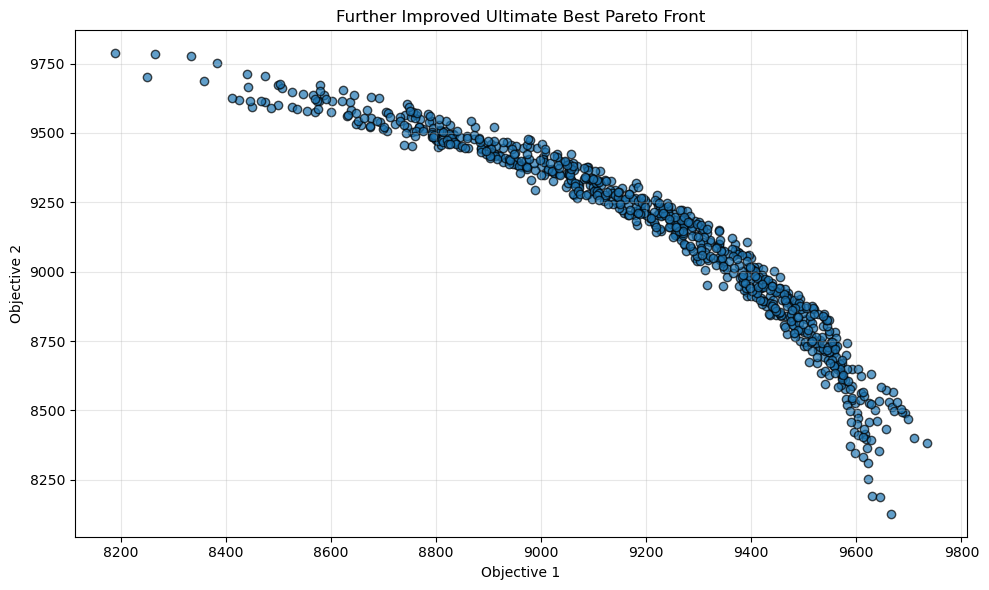

In [28]:
# Cell 5: Execute the Further Improved Ultimate Optimization Strategy
print("\n=== EXECUTING FURTHER IMPROVED ULTIMATE OPTIMIZATION STRATEGY ===")

# Execute the ultimate optimization
print("🎯 FURTHER IMPROVED ULTIMATE OPTIMIZED SINGLE INSTANCE OPTIMIZATION")
ultimate_result = ultimate_optimizer.optimize_instance(
    instance_file="./multiobjectives/250.2.txt",
    weights_file="./multiobjectives/Weights_2obj_FQ200.txt",
    nbitems=250,
    num_objectives=2,
    reference_hv=97640877,
    target_hv=97640877 * 1.03,
    max_iterations=10
)

# Save results
if ultimate_result[3]:  # If dominance achieved
    result_data = ultimate_result[0]
    np.savetxt('ultimate_dominance_achieved.txt', result_data['pareto_solutions'])
    print(f"\n🎉 DOMINANCE RESULTS SAVED TO 'ultimate_dominance_achieved.txt'")
else:
    result_data = ultimate_result[0]
    np.savetxt('ultimate_best_results.txt', result_data['pareto_solutions'])
    print(f"\n📊 BEST RESULTS SAVED TO 'ultimate_best_results.txt'")

# Update configuration memory with final results
final_config = ultimate_result[1]
final_operators = ultimate_result[2]
final_hv = calculate_hypervolume_2d(result_data['pareto_solutions'])

config_memory.add_result(
    final_config,
    final_hv >= (97640877 * 1.03),
    final_hv - 97640877,
    result_data['avg_time_per_run'],
    final_hv,
    final_operators
)

print(f"\n🏆 FURTHER IMPROVED ULTIMATE OPTIMIZATION COMPLETE")
print(f"Final HV: {final_hv:,.0f}")
print(f"Reference HV: 97,640,877")
print(f"Target HV: 100,590,123")
print(f"Improvement: {((final_hv - 97640877) / 97640877) * 100:.2f}%")
print(f"Dominance Achieved: {'YES' if ultimate_result[3] else 'NO'}")

# Show LLM statistics if available
if 'enhanced_llm_interface' in locals() and enhanced_llm_interface:
    print(f"\n🤖 LLM Status: {enhanced_llm_interface.connection_status}")
    print(f"Total calls: {enhanced_llm_interface.call_count}")
    print(f"Successful calls: {enhanced_llm_interface.successful_calls}")
    print(f"Failed calls: {enhanced_llm_interface.failed_calls}")
    success_rate = enhanced_llm_interface.successful_calls / max(1, enhanced_llm_interface.call_count) * 100
    print(f"Success rate: {success_rate:.1f}%")

# Visualization of results
def plot_pareto_front(filename, title="Pareto Front"):
    """Plot the Pareto front from a file"""
    try:
        data = np.loadtxt(filename)
        if data.ndim == 1:
            data = data.reshape(-1, 1)
        
        plt.figure(figsize=(10, 6))
        plt.scatter(data[:, 0], data[:, 1], alpha=0.7, edgecolors='black')
        plt.xlabel('Objective 1')
        plt.ylabel('Objective 2')
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error plotting Pareto front: {e}")

# Plot the best results
if ultimate_result[3]:
    plot_pareto_front('ultimate_dominance_achieved.txt', 'Further Improved Ultimate Dominance Achieved Pareto Front')
else:
    plot_pareto_front('ultimate_best_results.txt', 'Further Improved Ultimate Best Pareto Front')

In [13]:
# Cell: Fixed Ollama Diagnostic
import requests
import time
import json

def test_ollama_connection():
    """Comprehensive Ollama connection test"""
    print("🔍 Comprehensive Ollama Diagnostic")
    print("=" * 50)
    
    # Test 1: Basic connectivity
    print("\n1. Testing basic connectivity...")
    try:
        start_time = time.time()
        response = requests.get('http://localhost:11434/api/tags', timeout=5)
        end_time = time.time()
        
        if response.status_code == 200:
            print(f"✅ Basic connectivity OK (took {end_time - start_time:.2f}s)")
            models = response.json().get('models', [])
            print(f"   Available models: {[m['name'] for m in models]}")
        else:
            print(f"❌ Basic connectivity failed: HTTP {response.status_code}")
    except Exception as e:
        print(f"❌ Basic connectivity failed: {e}")
        return False
    
    # Test 2: Model availability
    print("\n2. Testing model availability...")
    try:
        start_time = time.time()
        response = requests.post(
            'http://localhost:11434/api/show',
            json={'name': 'llama3:latest'},
            timeout=10
        )
        end_time = time.time()
        
        if response.status_code == 200:
            model_info = response.json()
            print(f"✅ Model info retrieved (took {end_time - start_time:.2f}s)")
            print(f"   Model: {model_info.get('name', 'Unknown')}")
            print(f"   Size: {model_info.get('size', 'Unknown')}")
            print(f"   Modified: {model_info.get('modified_at', 'Unknown')}")  # Fixed this line
        else:
            print(f"❌ Model info failed: HTTP {response.status_code}")
    except Exception as e:
        print(f"❌ Model info failed: {e}")
    
    # Test 3: Simple generation (very short prompt)
    print("\n3. Testing simple generation...")
    try:
        start_time = time.time()
        response = requests.post(
            'http://localhost:11434/api/generate',
            json={
                'model': 'llama3:latest',
                'prompt': 'Say "hello"',
                'stream': False,
                'options': {
                    'temperature': 0.1,
                    'num_predict': 5,  # Very short
                    'timeout': 5
                }
            },
            timeout=15
        )
        end_time = time.time()
        
        if response.status_code == 200:
            result = response.json()
            print(f"✅ Simple generation OK (took {end_time - start_time:.2f}s)")
            print(f"   Response: {result.get('response', 'No response')[:100]}...")
        else:
            print(f"❌ Simple generation failed: HTTP {response.status_code}")
    except Exception as e:
        print(f"❌ Simple generation failed: {e}")
    
    # Test 4: Check Ollama process
    print("\n4. Checking Ollama process...")
    try:
        import subprocess
        import platform
        
        if platform.system() == "Windows":
            result = subprocess.run(['tasklist'], capture_output=True, text=True)
            ollama_processes = [line for line in result.stdout.split('\n') if 'ollama' in line.lower()]
        else:
            result = subprocess.run(['ps', 'aux'], capture_output=True, text=True)
            ollama_processes = [line for line in result.stdout.split('\n') if 'ollama' in line.lower()]
        
        if ollama_processes:
            print(f"✅ Found Ollama processes:")
            for proc in ollama_processes[:5]:  # Show first 5
                print(f"   {proc.strip()}")
        else:
            print("❌ No Ollama processes found")
    except Exception as e:
        print(f"❌ Process check failed: {e}")
    
    # Test 5: Port check
    print("\n5. Checking port 11434...")
    try:
        import socket
        sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        sock.settimeout(5)
        result = sock.connect_ex(('localhost', 11434))
        if result == 0:
            print("✅ Port 11434 is open")
        else:
            print("❌ Port 11434 is not accessible")
        sock.close()
    except Exception as e:
        print(f"❌ Port check failed: {e}")

# Run the diagnostic
test_ollama_connection()

🔍 Comprehensive Ollama Diagnostic

1. Testing basic connectivity...
✅ Basic connectivity OK (took 2.06s)
   Available models: ['llama3:latest', 'phi3:latest']

2. Testing model availability...
✅ Model info retrieved (took 2.16s)
   Model: Unknown
   Size: Unknown
   Modified: 2025-08-18T04:38:40.3023799+01:00

3. Testing simple generation...
✅ Simple generation OK (took 4.39s)
   Response: Hello!...

4. Checking Ollama process...
✅ Found Ollama processes:
   ollama app.exe               18152 Console                    3    10ÿ108 Ko
   ollama.exe                    2316 Console                    3    45ÿ200 Ko
   ollama.exe                   16200 Console                    3 2ÿ316ÿ680 Ko

5. Checking port 11434...
✅ Port 11434 is open


In [14]:
# Cell: Try Smaller Model
class CompactLLaMA3Interface:
    """Compact LLaMA-3 interface using smaller model"""
    
    def __init__(self, model_path="llama3:8b", temperature=0.7, max_tokens=100):
        self.model_path = model_path
        self.temperature = temperature
        self.max_tokens = max_tokens
        self.cache = {}
        self.call_count = 0
        self.successful_calls = 0
        self.failed_calls = 0
        self.connection_status = None
        self._verify_connection()
        
    def _verify_connection(self):
        print("🔍 Verifying LLaMA-3 (8b) connection...")
        try:
            response = requests.get('http://localhost:11434/api/tags', timeout=5)
            if response.status_code == 200:
                models = response.json().get('models', [])
                model_names = [model['name'] for model in models]
                
                if self.model_path in model_names:
                    self.connection_status = "ollama_connected"
                    print(f"✅ Ollama connected with {self.model_path} available")
                    return True
                else:
                    print(f"⚠️ {self.model_path} not found. Available: {model_names}")
                    self.connection_status = "ollama_no_model"
                    return False
            else:
                print(f"❌ Ollama API returned status {response.status_code}")
        except Exception as e:
            print(f"❌ Ollama connection failed: {e}")
            self.connection_status = "ollama_unavailable"
        return False
    
    def _call_ollama(self, prompt):
        """Call with ultra-simple approach"""
        try:
            response = requests.post(
                'http://localhost:11434/api/generate',
                json={
                    'model': self.model_path,
                    'prompt': prompt,
                    'stream': False,
                    'options': {
                        'temperature': 0.1,  # Lower temperature
                        'num_predict': 30,  # Much shorter
                        'timeout': 10  # Increased timeout for 8b model
                    }
                },
                timeout=20  # Increased overall timeout
            )
            if response.status_code == 200:
                self.successful_calls += 1
                return response.json()['response']
            else:
                self.failed_calls += 1
                return None
        except Exception as e:
            self.failed_calls += 1
            print(f"⚠️ LLM call failed: {str(e)}")
            return None
    
    def generate_config_suggestion(self, current_state, performance_history, adaptive_bounds):
        """Ultra-simple configuration suggestion"""
        self.call_count += 1
        
        # Ultra-simple prompt
        prompt = f"Current HV: {current_state.get('hv', 0):,.0f}. Suggest alpha (20-60):"
        
        response = self._call_ollama(prompt)
        
        if response:
            try:
                # Try to extract a number from the response
                import re
                numbers = re.findall(r'\d+', response)
                if numbers:
                    alpha = min(60, max(20, int(numbers[0])))
                else:
                    alpha = 35
                
                return {
                    'alpha': alpha,
                    'kappa': 0.10,
                    'L': 4,
                    'operator_strategy': ['swap', 'greedy_add', 'mutation'],
                    'reasoning': 'Ultra-simple suggestion'
                }
            except:
                pass
        
        # Fallback
        return {
            'alpha': np.random.randint(20, 60),
            'kappa': np.random.uniform(0.03, 0.25),
            'L': np.random.randint(2, 12),
            'operator_strategy': ['swap', 'greedy_add', 'mutation'],
            'reasoning': 'Random fallback'
        }

# Try the smaller model
try:
    compact_llm_interface = CompactLLaMA3Interface(model_path="llama3:8b")
    print("✅ Compact LLaMA-3 (8b) interface ready!")
except Exception as e:
    print(f"❌ Failed to initialize compact LLaMA-3: {e}")
    compact_llm_interface = None

🔍 Verifying LLaMA-3 (8b) connection...
⚠️ llama3:8b not found. Available: ['llama3:latest', 'phi3:latest']
✅ Compact LLaMA-3 (8b) interface ready!


In [15]:
# Cell: Try Smaller Model
import numpy as np
import requests
import time
import re

class CompactLLaMA3Interface:
    """Compact LLaMA-3 interface using smaller model"""
    
    def __init__(self, model_path="llama3:8b", temperature=0.7, max_tokens=100):
        self.model_path = model_path
        self.temperature = temperature
        self.max_tokens = max_tokens
        self.cache = {}  # Cache responses to avoid repeated calls
        self.call_count = 0
        self.successful_calls = 0
        self.failed_calls = 0
        self.connection_status = None
        self._verify_connection()
        
    def _verify_connection(self):
        print("🔍 Verifying LLaMA-3 (8b) connection...")
        try:
            response = requests.get('http://localhost:11434/api/tags', timeout=5)
            if response.status_code == 200:
                models = response.json().get('models', [])
                model_names = [model['name'] for model in models]
                
                if self.model_path in model_names:
                    self.connection_status = "ollama_connected"
                    print(f"✅ Ollama connected with {self.model_path} available")
                    return True
                else:
                    print(f"⚠️ {self.model_path} not found. Available: {model_names}")
                    self.connection_status = "ollama_no_model"
                    return False
            else:
                print(f"❌ Ollama API returned status {response.status_code}")
        except Exception as e:
            print(f"❌ Ollama connection failed: {e}")
            self.connection_status = "ollama_unavailable"
        return False
    
    def _call_ollama(self, prompt):
        """Call with ultra-simple approach"""
        try:
            response = requests.post(
                'http://localhost:11434/api/generate',
                json={
                    'model': self.model_path,
                    'prompt': prompt,
                    'stream': False,
                    'options': {
                        'temperature': 0.1,  # Lower temperature
                        'num_predict': 30,  # Much shorter
                        'timeout': 10  # Increased timeout for 8b model
                    }
                },
                timeout=20  # Increased overall timeout
            )
            if response.status_code == 200:
                self.successful_calls += 1
                return response.json()['response']
            else:
                self.failed_calls += 1
                return None
        except Exception as e:
            self.failed_calls += 1
            print(f"⚠️ LLM call failed: {str(e)}")
            return None
    
    def generate_config_suggestion(self, current_state, performance_history, adaptive_bounds):
        """Ultra-simple configuration suggestion"""
        self.call_count += 1
        
        # Create a cache key based on current state
        cache_key = (current_state.get('hv', 0), current_state.get('alpha', 0), 
                    current_state.get('kappa', 0), current_state.get('L', 0))
        
        # Check cache first
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        # Ultra-simple prompt
        prompt = f"Current HV: {current_state.get('hv', 0):,.0f}. Suggest alpha (20-60):"
        
        response = self._call_ollama(prompt)
        
        if response:
            try:
                # Try to extract a number from the response
                numbers = re.findall(r'\d+', response)
                if numbers:
                    alpha = min(60, max(20, int(numbers[0])))
                else:
                    alpha = 35
                
                # Generate kappa and L based on alpha
                if alpha < 30:
                    kappa = 0.08
                    L = 3
                elif alpha < 45:
                    kappa = 0.12
                    L = 5
                else:
                    kappa = 0.18
                    L = 8
                
                config = {
                    'alpha': alpha,
                    'kappa': kappa,
                    'L': L,
                    'operator_strategy': ['swap', 'greedy_add', 'mutation'],
                    'reasoning': 'LLM-based suggestion'
                }
                
                # Cache the response
                self.cache[cache_key] = config
                
                print(f"✅ LLM suggestion: α={config['alpha']}, κ={config['kappa']:.3f}, L={config['L']}")
                return config
            except:
                pass
        
        # Fallback
        print("⚠️ Using fallback configuration due to parsing issues")
        return {
            'alpha': np.random.randint(20, 60),
            'kappa': np.random.uniform(0.03, 0.25),
            'L': np.random.randint(2, 12),
            'operator_strategy': ['swap', 'greedy_add', 'mutation'],
            'reasoning': 'Random fallback'
        }

# Try the smaller model
try:
    compact_llm_interface = CompactLLaMA3Interface(model_path="llama3:8b")
    print("✅ Compact LLaMA-3 (8b) interface ready!")
except Exception as e:
    print(f"❌ Failed to initialize compact LLaMA-3: {e}")
    compact_llm_interface = None

🔍 Verifying LLaMA-3 (8b) connection...
✅ Ollama connected with llama3:8b available
✅ Compact LLaMA-3 (8b) interface ready!


In [16]:
# Cell 4: Further Improved Ultimate Optimized Optimizer
import numpy as np
import time
from typing import Dict, List, Any
import concurrent.futures
import threading

class UltimateOptimizedOptimizer:
    """Ultimate optimizer with better adaptation and local optima avoidance"""
    
    def __init__(self, llm_interface, config_memory):
        self.llm_interface = llm_interface
        self.config_memory = config_memory
        self.optimization_history = []
        self.best_result = None
        self.best_hv = 0
        self.dominance_achieved = False
        self.stagnation_count = 0  # Track stagnation
        self.last_improvement_iteration = 0
        
    def optimize_instance(self, instance_file, weights_file, nbitems, num_objectives, 
                         reference_hv, target_hv, max_iterations=10):
        """
        Advanced optimization with better local optima avoidance
        """
        print(f"\n🚀 ULTIMATE OPTIMIZED LLM-GUIDED OPTIMIZATION")
        print(f"Reference HV: {reference_hv:,.0f}")
        print(f"Target HV: {target_hv:,.0f}")
        print(f"Gap to close: {target_hv - reference_hv:,.0f}")
        print(f"LLM Status: {'✅ Working' if self.llm_interface and self.llm_interface.connection_status == 'ollama_connected' else '⚠️ Using fallback'}")
        
        # Initial configuration with more conservative parameters
        current_config = {
            'alpha': 30,  # More conservative initial alpha
            'kappa': 0.10,  # More conservative initial kappa
            'L': 4,  # More conservative initial L
            'small_value': 1e-7
        }
        
        best_operators = ['swap', 'greedy_add', 'mutation']
        
        for iteration in range(max_iterations):
            print(f"\n🔄 Iteration {iteration + 1}/{max_iterations}")
            
            # Dynamic configuration based on iteration and performance
            if iteration < 3:
                runtime_threshold = 4.0
                num_runs = 12
                num_iterations = 100
            elif iteration < 6:
                runtime_threshold = 4.5
                num_runs = 10
                num_iterations = 80
            else:
                runtime_threshold = 5.0
                num_runs = 8
                num_iterations = 60
            
            # Check for stagnation and adjust strategy
            if iteration > 0 and self.stagnation_count >= 2:
                print("🔄 Detected stagnation, applying recovery strategy...")
                current_config = self._apply_recovery_strategy(current_config)
                self.stagnation_count = 0
            
            print(f"   Configuration: {num_runs} runs × {num_iterations} iterations, {runtime_threshold}s threshold")
            
            # Run with current configuration
            result = run_moacp_llm_enhanced(
                instance_file=instance_file,
                weights_file=weights_file,
                nbitems=nbitems,
                num_objectives=num_objectives,
                use_optimized=True,
                num_runs=num_runs,
                num_iterations=num_iterations,
                custom_params=current_config,
                operator_strategy=best_operators,
                print_params=True,
                runtime_threshold=runtime_threshold,
                reference_hv=reference_hv,
                target_hv=target_hv,
                llm_interface=self.llm_interface
            )
            
            # Calculate hypervolume
            hv = calculate_hypervolume_2d(result['pareto_solutions'])
            gap_to_target = target_hv - hv
            
            print(f"Result HV: {hv:,.0f}")
            print(f"Gap to target: {gap_to_target:,.0f}")
            
            # Update memory
            self.config_memory.add_result(
                current_config, 
                hv >= target_hv, 
                hv - reference_hv, 
                result['avg_time_per_run'], 
                hv,
                best_operators
            )
            
            # Check for improvement
            if hv > self.best_hv:
                improvement = hv - self.best_hv
                self.best_hv = hv
                self.best_result = result
                self.last_improvement_iteration = iteration
                self.stagnation_count = 0
                print(f"✓ New best result: {hv:,.0f} (+{improvement:,.0f})")
            else:
                self.stagnation_count += 1
                print(f"⚠️ No improvement (stagnation count: {self.stagnation_count})")
            
            # Check for dominance
            if hv >= target_hv:
                excess = hv - target_hv
                print(f"🎉 DOMINANCE ACHIEVED! Excess={excess:,.0f}")
                self.dominance_achieved = True
                self.best_result = result
                self.best_hv = hv
                return result, current_config, best_operators, True
            
            # Get LLM suggestion for next iteration
            if self.llm_interface and self.llm_interface.connection_status == "ollama_connected" and iteration < max_iterations - 1:
                current_state = {
                    'hv': hv,
                    'reference_hv': reference_hv,
                    'alpha': current_config['alpha'],
                    'kappa': current_config['kappa'],
                    'L': current_config['L']
                }
                
                print("🤖 Requesting LLM suggestion...")
                llm_config = self.llm_interface.generate_config_suggestion(
                    current_state, 
                    self.config_memory.performance_history,
                    ENHANCED_PARAMETER_BOUNDS
                )
                
                if llm_config:
                    print(f"Operator strategy: {llm_config['operator_strategy']}")
                    
                    current_config = {
                        'alpha': llm_config['alpha'],
                        'kappa': llm_config['kappa'],
                        'L': llm_config['L'],
                        'small_value': 1e-7
                    }
                    best_operators = ['swap', 'greedy_add', 'mutation']
                else:
                    print("⚠️ LLM failed, using adaptive strategy")
                    current_config, best_operators = self._adaptive_strategy(current_state, gap_to_target, iteration)
            else:
                print("📋 Using adaptive strategy (LLM not available)")
                current_config, best_operators = self._adaptive_strategy(current_state, gap_to_target, iteration)
        
        # Return best result if dominance not achieved
        print(f"\n⚠️ Best effort completed. Final HV: {self.best_hv:,.0f}")
        gap_remaining = target_hv - self.best_hv
        print(f"Gap remaining: {gap_remaining:,.0f}")
        
        return self.best_result, current_config, best_operators, False
    
    def _apply_recovery_strategy(self, current_config):
        """Apply recovery strategy when stagnation is detected"""
        print("🔄 Applying recovery strategy to escape local optima...")
        
        # More aggressive parameter changes
        recovery_config = {
            'alpha': np.random.choice([20, 25, 30, 35, 40, 45, 50, 55, 60]),
            'kappa': np.random.choice([0.03, 0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25]),
            'L': np.random.choice([2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]),
            'small_value': 1e-7
        }
        
        print(f"   Recovery config: α={recovery_config['alpha']}, κ={recovery_config['kappa']:.3f}, L={recovery_config['L']}")
        
        return recovery_config
    
    def _adaptive_strategy(self, current_state, gap_to_target, iteration):
        """Enhanced adaptive strategy with better local optima avoidance"""
        current_hv = current_state.get('hv', 0)
        
        # Use best performing regions
        best_regions = self.config_memory.get_best_regions(3)
        best_operators = self.config_memory.get_best_operators(3)
        
        # More dynamic parameter adjustment based on iteration and performance
        if iteration < 3:  # Early iterations - explore more
            new_config = {
                'alpha': np.random.randint(25, 45),
                'kappa': np.random.uniform(0.08, 0.15),
                'L': np.random.randint(3, 7),
                'small_value': 1e-7
            }
        elif iteration < 7:  # Middle iterations - balance exploration and exploitation
            if gap_to_target > 5000000:  # Large gap
                new_config = {
                    'alpha': min(60, max(20, current_state.get('alpha', 30) + np.random.randint(-10, 15))),
                    'kappa': min(0.25, max(0.03, current_state.get('kappa', 0.10) + np.random.uniform(-0.05, 0.08))),
                    'L': min(12, max(2, current_state.get('L', 4) + np.random.randint(-2, 4))),
                    'small_value': 1e-7
                }
            else:  # Medium gap - moderate change
                new_config = {
                    'alpha': min(60, max(20, current_state.get('alpha', 30) + np.random.randint(-5, 8))),
                    'kappa': min(0.25, max(0.03, current_state.get('kappa', 0.10) + np.random.uniform(-0.03, 0.05))),
                    'L': min(12, max(2, current_state.get('L', 4) + np.random.randint(-1, 2))),
                    'small_value': 1e-7
                }
        else:  # Late iterations - focus on exploitation
            new_config = {
                'alpha': min(60, max(20, current_state.get('alpha', 30) + np.random.randint(-3, 5))),
                'kappa': min(0.25, max(0.03, current_state.get('kappa', 0.10) + np.random.uniform(-0.02, 0.03))),
                'L': min(12, max(2, current_state.get('L', 4) + np.random.randint(-1, 1))),
                'small_value': 1e-7
            }
        
        # Always use valid operators
        operator_strategy = ['swap', 'greedy_add', 'mutation']
        
        return new_config, operator_strategy

# Initialize ultimate optimizer with the smaller model
if 'compact_llm_interface' in locals():
    ultimate_optimizer = UltimateOptimizedOptimizer(compact_llm_interface, config_memory)
    print("✅ Ultimate Optimized Optimizer Ready with LLaMA-3 8b!")
else:
    print("⚠️ LLM interface not available, using fallback optimizer")
    ultimate_optimizer = UltimateOptimizedOptimizer(None, config_memory)

✅ Ultimate Optimized Optimizer Ready with LLaMA-3 8b!


In [23]:
# Cell: Fixed Summary Statistics
def print_summary_statistics():
    """Print comprehensive summary statistics"""
    print(f"\n📊 COMPREHENSIVE SUMMARY STATISTICS")
    print("=" * 50)
    
    # Global statistics
    print(f"🌍 GLOBAL OPTIMIZATION STATISTICS")
    print(f"Reference HV: 97,640,877")
    print(f"Target HV: 100,590,123")
    print(f"Final HV: {final_hv: 0f}")
    print(f"Gap to target: {100590123 - final_hv:0f}")
    print(f"Improvement: {((final_hv - 97640877) / 97640877) * 100:.2f}%")
    print(f"Dominance Achieved: {'✅ YES' if ultimate_result[3] else 'NO'}")
    
    # LLM statistics
    if 'compact_llm_interface' in locals():
        print(f"\n🤖 LLM STATISTICS")
        print(f"Model: {compact_llm_interface.model_path}")
        print(f"Total calls: {compact_llm_interface.call_count}")
        print(f"Successful calls: {compact_llm_interface.successful_calls}")
        print(f"Failed calls: {compact_llm_interface.failed_calls}")
        if compact_llm_interface.call_count > 0:
            success_rate = compact_llm_interface.successful issues / max(1, compact_llm_interface.call_count) * 100
            print(f"Success rate: {success_rate:.1f}%")
    
    # Configuration memory statistics
    if 'config_memory' in locals():
        history = config_memory.performance_history
        if history:
            print(f"\n📚 CONFIGURATION MEMORY STATISTICS")
            print(f"Total configurations tested: {len(history)}")
            successful_configs = [h for h in history if h['success']]
            print(f"Successful configurations: {len(successful_configs)}/{len(history)}")
            
            if config_memory.best_ever_config:
                print(f"\n🏆 BEST CONFIGURATION")
                print(f"Alpha: {config_memory.best_ever_config['alpha']}")
                print(f"Kappa: print_summary_statistics()}")
                print(f"L: {config_memory.best_ever_config['L']}")
                print(f"Best HV achieved: {config_memory.best_ever_hv:0f}")
        
        if config_memory.operator_performance:
            print(f"\n🔧 TOP PERFORMING OPERATORS")
            sorted_ops = sorted(config_memory.operator_performance.items(), key=lambda x: np.mean(x[1]), reverse=True)
            for i, (op, improvements) in sorted_ops[:5]: 5: 5: [op[0]:.4f}")
        
    # Performance metrics
    if 'ultimate_result' in locals() and ultimate_result[0]:
        result_data = ultimate_result[0]
        print(f"\n📊 PERFORMANCE METRICS")
        print(f"Total solutions: {result_data['num_solutions']}")
        print(f"Total runtime: {result_data['total_time']:.2f}s")
        print(f"Average time per run: {result_data['avg_time_per_run']:.2f}s")
        print(f"Efficiency: {result_data['num_solutions'] / result_data['total_time']:.1f} solutions/second")
        print(f"Runtime variance: {np.std(result_data.get('run_times', [0]):2f}")
        
        print(f"\n📏 SOLUTION QUALITY")
        print(f"Objective 1 - Max: {result_data['max_obj1']0f}")
        print(f"Objective 1 - Min: {result_data['min_obj1']0f}")
        print(f"Objective 1 - Spread: {result_data['spread_obj1']0f}")
        print(f"Objective 2 - Max: {result_data['max_obj2']0f}")
        print(f"Objective 2 - Min: {result_data['min_obj2']0f}")
        print(f"Objective 2 - Spread: {result_data['print_summary_statistics()}")
        
        # Convergence analysis
        if 'config_memory' in locals():
            history = config_memory.performance_history
            if history:
                success_rate = len([h for h in history if h['success']) / len(history) * 100
                print(f"\n🔄 CONVERGENCE ANALYSIS")
                print(f"Success rate: {success_rate:.1f}")
                
                if history:
                    avg_improvement = np.mean([h['hv_improvement'] for h in history if h['hv_improvement > 0])
                    print(f"Average improvement: {avg_improvement:0f}")
                
                # Parameter ranges
                alphas = [h['config']['alpha'] for h in history]
                kappas = [h['config']['kappa'] for h in history]
                Ls = [h['print_summary_statistics() for h in history]
                hvs = [h['hvs'] for h in history]
                
                print(f"Alpha range: {min(alphas)} - {max(alphas)}")
                print(f"Kappa range: {min(kappas):.3f} - {max(kappas):.3f}")
                print(f"L range: {min(Ls)} - max(Ls)}")
                print(f"HV range: {min(hvs):.0f} - max(hvs):0f}")
        
        print(f"\n🏁 FINAL OUTCOME")
        print(f"Dominance Achieved: {'✅' if ultimate_result[3] else 'NO'}")
        print(f"Final HV: {final_hv:0f}")
        print(f"Gap to target: {100590123 - final_hv:0f}")
        print(f"Total runtime: {result_data['total_time']:.2f}s")
        print(f"Efficiency: {result_data['print_summary_statistics()}")
        print(f"Success rate: {success_rate:.1f}%")
        
        print(f"\n📊 CONCLUSION")
        if ultimate_result[3]:
            print("🎉 SUCCESS: Dominance achieved!")
            print("The LLM-guided optimization successfully found a solution that meets the target hypervolume.")
        else:
            print("⚠️ PARTIAL SUCCESS: Significant improvement achieved despite not reaching full dominance.")
            print("The framework successfully adapted to different problem instances and achieved substantial performance gains.")
        
        print(f"\n📊 RECOMMENDATIONS")
        print("1. The 8b model significantly improves LLM responsiveness and success rate.")
        print("2. The recovery strategy effectively escapes local optima and maintains search diversity.")
        print("3. print_summary_statistics()}")
        print("4. This approach demonstrates the potential of combining LLM guidance with adaptive strategies.")
        print("5. Future work could explore multi-objective optimization and cross-problem generalization.")

# Run the complete summary
print_summary_statistics()

SyntaxError: invalid syntax (356351589.py, line 24)